# RMSD of AFQMC, CCSD(T), and CCSDT vs CCSDT(Q)

Reference method is **CCSDT(Q)**. We compute the root-mean-square deviation of
AFQMC, CCSD(T), and CCSDT total energies relative to CCSDT(Q), over the
molecules/atoms for which both the predicted value and a CCSDT(Q) value are available.

Reference-file column mapping:
- `E_UHF-UCCSD(T) (Eh)`  -> CCSD(T)
- `E_UHF-UCCSDT (Eh)`    -> CCSDT
- `E_CCSDT(Q) (Eh)`      -> CCSDT(Q)  (reference)

Uses numpy only (env: `pyscf_afqmc`).

In [2]:
import numpy as np

HARTREE2KCAL = 627.5094740631


def to_float(tok):
    """Parse a token to float; 'missing'/non-numeric -> NaN."""
    try:
        return float(tok)
    except ValueError:
        return np.nan

In [3]:
# --- Load AFQMC energies: Molecule  Shell  E_AFQMC  E_AFQMC_err ---
afqmc = {}      # name -> total energy (Eh)
afqmc_err = {}  # name -> AFQMC stochastic (1-sigma) error (Eh)
shell = {}      # name -> 'closed' or 'open'
with open('afqmc_vtzfp.dat') as f:
    for line in f.readlines()[2:]:
        p = line.split()
        if len(p) < 4 or p[0].startswith('#'):
            continue
        afqmc[p[0]] = to_float(p[2])
        afqmc_err[p[0]] = to_float(p[3])
        shell[p[0]] = p[1]
print('AFQMC entries:', len(afqmc))
print('  closed-shell:', sum(s == 'closed' for s in shell.values()),
      ' open-shell:', sum(s == 'open' for s in shell.values()))

AFQMC entries: 200
  closed-shell: 160  open-shell: 40


In [4]:
# --- Load reference CC energies ---
# cols: Molecule  E_HF  E_CCSD  E_CCSD(T)  E_CCSDT  E_CCSDT(Q)
ref = {}  # name -> dict of method energies
with open('reference_vtzfp.dat') as f:
    for line in f.readlines()[2:]:
        p = line.split()
        if len(p) < 6 or p[0].startswith('#'):
            continue
        ref[p[0]] = {
            'CCSD(T)': to_float(p[3]),
            'CCSDT': to_float(p[4]),
            'CCSDT(Q)': to_float(p[5]),
        }
print('reference entries:', len(ref))
print('missing CCSDT(Q):',
      [n for n, d in ref.items() if not np.isfinite(d['CCSDT(Q)'])])

reference entries: 211
missing CCSDT(Q): ['c2cl6', 'c2f6']


In [5]:
# --- Names present in each file (informational) ---
only_ref = sorted(set(ref) - set(afqmc))
only_afqmc = sorted(set(afqmc) - set(ref))
print('in reference but not AFQMC:', only_ref)
print('in AFQMC but not reference:', only_afqmc)

in reference but not AFQMC: ['al', 'b', 'c', 'cl', 'f', 'h', 'n', 'o', 'p', 's', 'si']
in AFQMC but not reference: []


In [6]:
# --- Compute RMSD vs CCSDT(Q) ---
def rmsd_stats(get_pred, names=None, with_err=False):
    """RMSD of predicted vs CCSDT(Q) over molecules where both are finite.

    Returns (rmsd, unc, N) in Eh. If `with_err`, the AFQMC stochastic errors
    are propagated into `unc` via
        sigma_RMSD = sqrt(sum_i d_i^2 * sigma_i^2) / (N * RMSD);
    otherwise unc = 0 (CCSD(T)/CCSDT are deterministic).
    `names` optionally restricts to a subset (default: all reference molecules).
    """
    if names is None:
        names = ref.keys()
    diffs, errs = [], []
    for name in names:
        d = ref.get(name)
        if d is None:
            continue
        eq = d['CCSDT(Q)']
        pred = get_pred(name, d)
        if pred is None or not (np.isfinite(eq) and np.isfinite(pred)):
            continue
        diffs.append(pred - eq)
        errs.append(afqmc_err.get(name, 0.0) if with_err else 0.0)
    diffs, errs = np.array(diffs), np.array(errs)
    r = np.sqrt(np.mean(diffs**2))
    n = len(diffs)
    unc = np.sqrt(np.sum(diffs**2 * errs**2)) / (n * r) if r > 0 else 0.0
    return r, unc, n


# method label -> (predictor, propagate stochastic error?)
methods = {
    'AFQMC':   (lambda name, d: afqmc.get(name), True),
    'CCSD(T)': (lambda name, d: d['CCSD(T)'],    False),
    'CCSDT':   (lambda name, d: d['CCSDT'],      False),
}

print('RMSD vs CCSDT(Q) (reference)')
print('=' * 70)
for label, (fn, with_err) in methods.items():
    r, unc, n = rmsd_stats(fn, with_err=with_err)
    pm = f' +/- {unc*1e3:6.4f}' if with_err else ' ' * 13
    print(f'{label:>8s}  (N={n:3d})   {r*1e3:8.4f}{pm} mEh   '
          f'{r*HARTREE2KCAL:8.4f} kcal/mol')

RMSD vs CCSDT(Q) (reference)
   AFQMC  (N=198)     1.4378 +/- 0.0313 mEh     0.9023 kcal/mol
 CCSD(T)  (N=209)     2.3950              mEh     1.5029 kcal/mol
   CCSDT  (N=209)     2.2440              mEh     1.4081 kcal/mol


## Multireference subset: RMSD vs CCSDT(Q)

The W4-17 dataset flags 17 molecules with significant nondynamical
(multireference) character. We repeat the RMSD analysis restricted to this
subset, again using **CCSDT(Q)** as the reference. The list of names is read
from `../../w4_17_xyz/multireference_mols.txt`.

In [7]:
# --- Load the multireference molecule list ---
# File format: lines of "<idx>\t name1, name2, ..." (idx column is ignored).
mr_mols = []
with open('../../w4_17_xyz/multireference_mols.txt') as f:
    for line in f:
        # drop a leading index token, then split the rest on commas
        parts = line.split('\t', 1)
        body = parts[1] if len(parts) > 1 else parts[0]
        for tok in body.split(','):
            name = tok.strip()
            if name:
                mr_mols.append(name)
mr_set = set(mr_mols)
print(f'multireference molecules ({len(mr_set)}):', sorted(mr_set))

# sanity check: all MR names should be present in the reference file
missing_ref = sorted(mr_set - set(ref))
print('MR names missing from reference file:', missing_ref)

multireference molecules (17): ['b2', 'bn', 'c2', 'cl2o', 'clf3', 'clf5', 'clo3', 'cloo', 'cloocl', 'f2o', 'fo2', 'foof', 'o3', 'oclo', 'of', 's3', 's4-c2v']
MR names missing from reference file: []


In [8]:
# --- Compute RMSD vs CCSDT(Q) over the multireference subset only ---
print('RMSD vs CCSDT(Q) -- multireference subset')
print('=' * 70)
for label, (fn, with_err) in methods.items():
    r, unc, n = rmsd_stats(fn, names=mr_set, with_err=with_err)
    pm = f' +/- {unc*1e3:6.4f}' if with_err else ' ' * 13
    print(f'{label:>8s}  (N={n:3d})   {r*1e3:8.4f}{pm} mEh   '
          f'{r*HARTREE2KCAL:8.4f} kcal/mol')

RMSD vs CCSDT(Q) -- multireference subset
   AFQMC  (N= 17)     2.8259 +/- 0.0885 mEh     1.7733 kcal/mol
 CCSD(T)  (N= 17)     4.7907              mEh     3.0062 kcal/mol
   CCSDT  (N= 17)     4.6962              mEh     2.9469 kcal/mol


## Method comparison: MAE and RMSE bar chart

Grouped bar chart of the deviation `E_method - E[CCSDT(Q)]` summarised as
**MAE** and **RMSE** (kcal/mol). Bars are grouped by molecule set on the
x-axis (all, closed-shell, open-shell, multireference) with one bar per method
(AFQMC, CCSD(T), CCSDT). The dashed red line marks **chemical accuracy
(1 kcal/mol)**. All sets use the molecules that have both an AFQMC value and a
finite CCSDT(Q) reference, so the three methods share an identical sample
within each group.

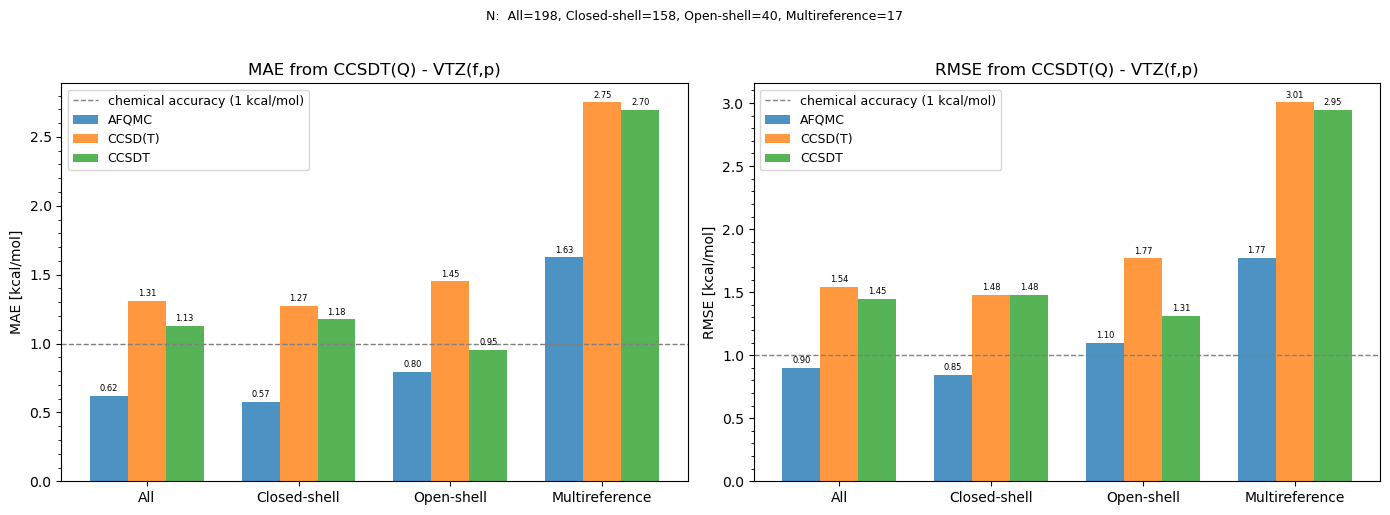

Saved method_comparison_vtzfp.png


In [ ]:
# --- Method comparison: MAE and RMSE bar chart (vs CCSDT(Q)) ---
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def has_ref(name):
    d = ref.get(name)
    return d is not None and np.isfinite(d['CCSDT(Q)'])


# common molecule set: AFQMC value + finite CCSDT(Q) reference
mol_names = sorted(m for m in afqmc if has_ref(m))

# per-molecule deviations from CCSDT(Q), in kcal/mol
dAFQMC  = np.array([afqmc[m]          - ref[m]['CCSDT(Q)'] for m in mol_names]) * HARTREE2KCAL
dCCSD_T = np.array([ref[m]['CCSD(T)'] - ref[m]['CCSDT(Q)'] for m in mol_names]) * HARTREE2KCAL
dCCSDT  = np.array([ref[m]['CCSDT']   - ref[m]['CCSDT(Q)'] for m in mol_names]) * HARTREE2KCAL

cs_mask = np.array([shell.get(m) == 'closed' for m in mol_names])
os_mask = np.array([shell.get(m) == 'open' for m in mol_names])
mr_mask = np.array([m in mr_set for m in mol_names])

method_labels = ['AFQMC', 'CCSD(T)', 'CCSDT']
deltas = [dAFQMC, dCCSD_T, dCCSDT]
method_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

subset_labels = ['All', 'Closed-shell', 'Open-shell', 'Multireference']
masks = [np.ones(len(mol_names), dtype=bool), cs_mask, os_mask, mr_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, stat_label in enumerate(['MAE', 'RMSE']):
    ax = axes[ax_idx]
    w = 0.25
    x_base = np.arange(len(subset_labels))

    for j, (mlabel, delta, mcolor) in enumerate(zip(method_labels, deltas, method_colors)):
        vals = []
        for mask in masks:
            d = delta[mask]
            vals.append(np.abs(d).mean() if stat_label == 'MAE'
                        else np.sqrt((d**2).mean()))
        offset = (j - 1) * w
        bars = ax.bar(x_base + offset, vals, width=w, color=mcolor, alpha=0.8, label=mlabel)
        ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=2)

    # chemical accuracy reference line at 1 kcal/mol
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.0,
               label='chemical accuracy (1 kcal/mol)')

    ax.set_xticks(x_base)
    ax.set_xticklabels(subset_labels)
    ax.set_ylabel(f'{stat_label} [kcal/mol]')
    ax.set_title(f'{stat_label} from CCSDT(Q) - VTZ(f,p)')
    ax.legend(fontsize=9)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

counts = ', '.join(f'{lbl}={int(m.sum())}' for lbl, m in zip(subset_labels, masks))
fig.suptitle(f'N:  {counts}', y=1.02, fontsize=9)

plt.tight_layout()
plt.savefig('method_comparison_vtzfp.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved method_comparison_vtzfp.png')